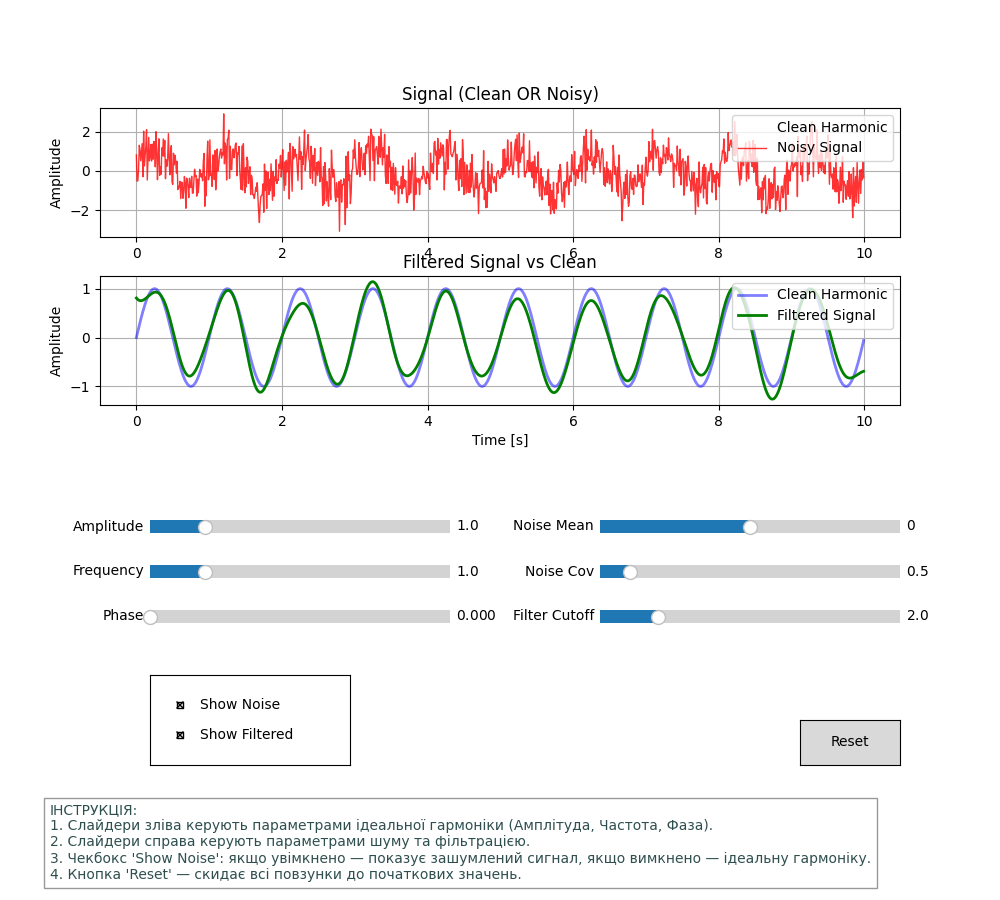

In [5]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import butter, filtfilt

fs = 100.0  
t = np.linspace(0, 10, int(10 * fs), endpoint=False)
base_noise = np.random.normal(0, 1, len(t))
INIT_AMP = 1.0
INIT_FREQ = 1.0
INIT_PHASE = 0.0
INIT_NOISE_MEAN = 0.0
INIT_NOISE_COV = 0.5
INIT_CUTOFF = 2.0  

def harmonic_with_noise(amplitude, frequency, phase, noise_mean, noise_cov):
    y_clean = amplitude * np.sin(2 * np.pi * frequency * t + phase)
    noise = noise_mean + np.sqrt(noise_cov) * base_noise 
    y_noisy = y_clean + noise
    return y_clean, y_noisy

def apply_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    if normal_cutoff >= 1.0: normal_cutoff = 0.99 
    if normal_cutoff <= 0: normal_cutoff = 0.01
        
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y_filtered = filtfilt(b, a, data)
    return y_filtered

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9))
plt.subplots_adjust(left=0.1, bottom=0.55, hspace=0.3) # Трохи підняли графіки

y_clean, y_noisy = harmonic_with_noise(INIT_AMP, INIT_FREQ, INIT_PHASE, INIT_NOISE_MEAN, INIT_NOISE_COV)
y_filtered = apply_filter(y_noisy, INIT_CUTOFF, fs)
line_clean1, = ax1.plot(t, y_clean, lw=2, color='blue', label='Clean Harmonic', visible=False)
line_noisy, = ax1.plot(t, y_noisy, lw=1, color='red', alpha=0.8, label='Noisy Signal')
ax1.set_title('Signal (Clean OR Noisy)')
ax1.set_ylabel('Amplitude')
ax1.legend(loc='upper right')
ax1.grid(True)
line_clean2, = ax2.plot(t, y_clean, lw=2, color='blue', label='Clean Harmonic', alpha=0.5)
line_filtered, = ax2.plot(t, y_filtered, lw=2, color='green', label='Filtered Signal')
ax2.set_title('Filtered Signal vs Clean')
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Amplitude')
ax2.legend(loc='upper right')
ax2.grid(True)

ax_amp    = plt.axes([0.15, 0.40, 0.3, 0.03])
ax_freq   = plt.axes([0.15, 0.35, 0.3, 0.03])
ax_phase  = plt.axes([0.15, 0.30, 0.3, 0.03])
ax_n_mean = plt.axes([0.60, 0.40, 0.3, 0.03])
ax_n_cov  = plt.axes([0.60, 0.35, 0.3, 0.03])
ax_cutoff = plt.axes([0.60, 0.30, 0.3, 0.03])

sl_amp    = Slider(ax_amp, 'Amplitude', 0.1, 5.0, valinit=INIT_AMP)
sl_freq   = Slider(ax_freq, 'Frequency', 0.1, 5.0, valinit=INIT_FREQ)
sl_phase  = Slider(ax_phase, 'Phase', 0.0, 2*np.pi, valinit=INIT_PHASE)
sl_n_mean = Slider(ax_n_mean, 'Noise Mean', -2.0, 2.0, valinit=INIT_NOISE_MEAN)
sl_n_cov  = Slider(ax_n_cov, 'Noise Cov', 0.0, 5.0, valinit=INIT_NOISE_COV)
sl_cutoff = Slider(ax_cutoff, 'Filter Cutoff', 0.1, 10.0, valinit=INIT_CUTOFF)

ax_check = plt.axes([0.15, 0.15, 0.2, 0.1])
check = CheckButtons(ax_check, ['Show Noise', 'Show Filtered'], [True, True])
ax_reset = plt.axes([0.8, 0.15, 0.1, 0.05])
btn_reset = Button(ax_reset, 'Reset', hovercolor='0.975')

fig.text(0.05, 0.02, 
         "ІНСТРУКЦІЯ:\n"
         "1. Слайдери зліва керують параметрами ідеальної гармоніки (Амплітуда, Частота, Фаза).\n"
         "2. Слайдери справа керують параметрами шуму та фільтрацією.\n"
         "3. Чекбокс 'Show Noise': якщо увімкнено — показує зашумлений сигнал, якщо вимкнено — ідеальну гармоніку.\n"
         "4. Кнопка 'Reset' — скидає всі повзунки до початкових значень.", 
         fontsize=10, color='darkslategray', va='bottom', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

def update(val):
    clean, noisy = harmonic_with_noise(
        sl_amp.val, sl_freq.val, sl_phase.val, sl_n_mean.val, sl_n_cov.val
    )
    filtered = apply_filter(noisy, sl_cutoff.val, fs)
    line_clean1.set_ydata(clean)
    line_clean2.set_ydata(clean)
    line_noisy.set_ydata(noisy)
    line_filtered.set_ydata(filtered)
    fig.canvas.draw_idle()

def toggle_lines(label):
    if label == 'Show Noise':
        is_noise_on = not line_noisy.get_visible()
        line_noisy.set_visible(is_noise_on)
        line_clean1.set_visible(not is_noise_on)
    elif label == 'Show Filtered':
        line_filtered.set_visible(not line_filtered.get_visible())
    fig.canvas.draw_idle()

def reset_all(event):
    sl_amp.reset()
    sl_freq.reset()
    sl_phase.reset()
    sl_n_mean.reset()
    sl_n_cov.reset()
    sl_cutoff.reset()

sl_amp.on_changed(update)
sl_freq.on_changed(update)
sl_phase.on_changed(update)
sl_n_mean.on_changed(update)
sl_n_cov.on_changed(update)
sl_cutoff.on_changed(update)
check.on_clicked(toggle_lines)
btn_reset.on_clicked(reset_all)

plt.show()